In [ ]:
#import libraries
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
#import dataset from Kaggle directly
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devbatrax/fracture-detection-using-x-ray-images")

print("Path to dataset files:", path)

100%|██████████| 172M/172M [00:01<00:00, 151MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1


In [ ]:
#check where dataset is located
print(path)

/root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1


In [ ]:
#what folder is inside download
os.listdir(path)

['data']

In [ ]:
#how data has been structured inside the 'data' folder
for root, dirs, files in os.walk(path):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", len(files))
    print("-" * 50)

ROOT: /root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1
DIRS: ['data']
FILES: 0
--------------------------------------------------
ROOT: /root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1/data
DIRS: ['train', 'val']
FILES: 0
--------------------------------------------------
ROOT: /root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1/data/train
DIRS: ['not fractured', 'fractured']
FILES: 0
--------------------------------------------------
ROOT: /root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1/data/train/not fractured
DIRS: []
FILES: 4383
--------------------------------------------------
ROOT: /root/.cache/kagglehub/datasets/devbatrax/fracture-detection-using-x-ray-images/versions/1/data/train/fractured
DIRS: []
FILES: 4480
--------------------------------------------------
ROOT: /root/.cache/kagglehub/datasets/devbatrax/fractu

In [ ]:
#root directory is hidden by default, we copy dataset to 'content' folder to see the contents of it
import shutil
shutil.copytree(path, "/content/fracture_dataset")

'/content/fracture_dataset'

In [ ]:
dataset_path = "/content/fracture_dataset"

In [ ]:
#set training and validation paths
train_dir = path + "/data/train"
val_dir = path + "/data/val"

In [ ]:
#Change image attributes to produce images of the same subjects but altered for training dataset
#This will allow better generalization of model
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
#Normalize validation dataset (no alteration since we predict on this dataset)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
#Training dataset setup
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 8863 images belonging to 2 classes.


In [ ]:
#Validation dataset setup
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 600 images belonging to 2 classes.


In [ ]:
#check if labels are correct('0' for no and '1' for yes)
print(train_generator.class_indices)

{'fractured': 0, 'not fractured': 1}


In [ ]:
#CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Measuring loss and optimizing according to it
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#View model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#Training CNN Model
history = model.fit(train_generator, validation_data=val_generator, epochs = 15)

Epoch 1/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 62s 191ms/step - accuracy: 0.5824 - loss: 0.8257 - val_accuracy: 0.5733 - val_loss: 0.6681
Epoch 2/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 68s 167ms/step - accuracy: 0.6229 - loss: 0.6499 - val_accuracy: 0.6583 - val_loss: 0.7392
Epoch 3/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 166ms/step - accuracy: 0.6455 - loss: 0.6360 - val_accuracy: 0.6817 - val_loss: 0.5483
Epoch 4/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.6640 - loss: 0.5975 - val_accuracy: 0.6550 - val_loss: 0.5454
Epoch 5/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 45s 163ms/step - accuracy: 0.6943 - loss: 0.5646 - val_accuracy: 0.6583 - val_loss: 0.5597
Epoch 6/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 47s 168ms/step - accuracy: 0.7064 - loss: 0.5502 - val_accuracy: 0.4950 - val_loss: 0.7148
Epoch 7/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 165ms/step - accuracy: 0.7162 - loss: 0.5385 - val_accuracy: 0.7250 - val_loss: 0.4825
Epoch 8/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 166ms/step - accuracy: 0.7329 - loss: 0

In [ ]:
#Reduce Epochs and introduce callbacks to see if Accuracy improves(reduce overfitting)
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs = 10,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor='val_loss',
                        patience=3,
                        restore_best_weights=True)])

Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 47s 169ms/step - accuracy: 0.8560 - loss: 0.3096 - val_accuracy: 0.5850 - val_loss: 1.6176
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 47s 168ms/step - accuracy: 0.8743 - loss: 0.2814 - val_accuracy: 0.6650 - val_loss: 1.1408
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 47s 169ms/step - accuracy: 0.8766 - loss: 0.2773 - val_accuracy: 0.6483 - val_loss: 1.2340
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 165ms/step - accuracy: 0.8930 - loss: 0.2491 - val_accuracy: 0.6000 - val_loss: 1.4072
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 166ms/step - accuracy: 0.9008 - loss: 0.2358 - val_accuracy: 0.6867 - val_loss: 1.0315
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 44s 160ms/step - accuracy: 0.9066 - loss: 0.2240 - val_accuracy: 0.6867 - val_loss: 1.3279
Epoch 7/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.9185 - loss: 0.1955 - val_accuracy: 0.6467 - val_loss: 1.1511
Epoch 8/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 46s 167ms/step - accuracy: 0.9217 - loss: 0

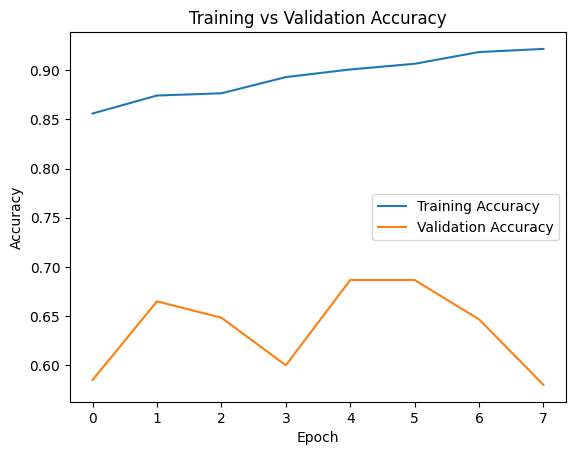

In [ ]:
#Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

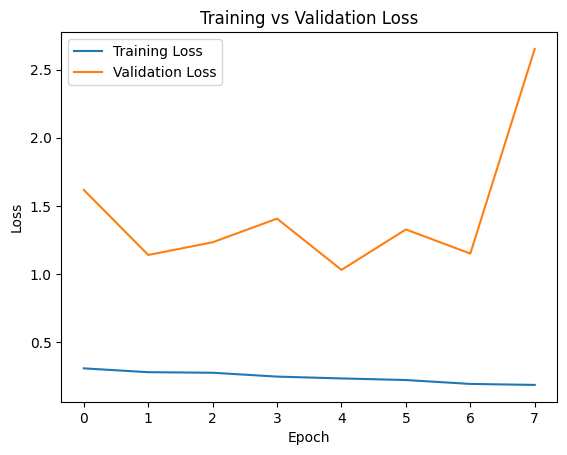

In [ ]:
#Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#Classification Report
predictions = model.predict(val_generator)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = val_generator.classes

print(classification_report(true_classes, predicted_classes))

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step
              precision    recall  f1-score   support

           0       0.79      0.66      0.72       360
           1       0.59      0.73      0.65       240

    accuracy                           0.69       600
   macro avg       0.69      0.69      0.68       600
weighted avg       0.71      0.69      0.69       600



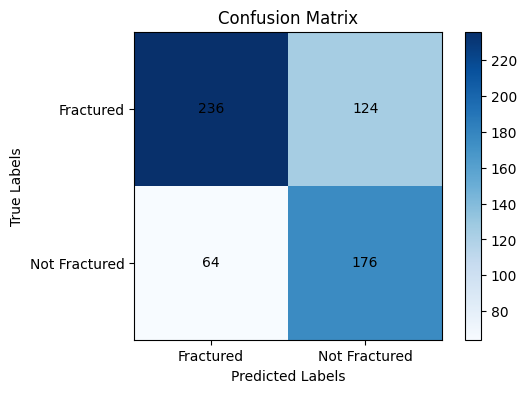

In [ ]:
#Confusion Matrix with Heatmap
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Fractured', 'Not Fractured'])
plt.yticks([0, 1], ['Fractured', 'Not Fractured'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

for i in range(2):
  for j in range(2):
    plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.show()

In [ ]:
#Using pre-trained model MobileNetV2 now

In [ ]:
#Normalize dataset for pre-trained model
train_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input)
val_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input)

In [ ]:
#Pre-trained models' training dataset setup
train_generator_mobilenet = train_datagen_mobilenet.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 8863 images belonging to 2 classes.


In [ ]:
#Pre-trained models' validation dataset setup
val_generator_mobilenet = val_datagen_mobilenet.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 600 images belonging to 2 classes.


In [ ]:
#Load pre-trained model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

In [ ]:
#Transfer Learning through CNN Model
model_mobilenet = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
#Compilation and Loss Optimizer
model_mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#View pre-trained model
model_mobilenet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     8,028,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,286,401 (39.24 MB)

 Trainable params: 8,028,417 (30.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Train pre-trained model with the given dataset
history_mobilenet = model_mobilenet.fit(train_generator_mobilenet,
                                        validation_data=val_generator_mobilenet,
                                        epochs = 10,
                                        callbacks=[tf.keras.callbacks.EarlyStopping(
                                            monitor='val_loss',
                                            patience=3,
                                            restore_best_weights=True)
                                        ])

Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.8417 - loss: 0.9702 - val_accuracy: 0.7667 - val_loss: 0.6045
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9367 - loss: 0.1485 - val_accuracy: 0.8017 - val_loss: 0.5795
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.9564 - loss: 0.1007 - val_accuracy: 0.8200 - val_loss: 0.5351
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9569 - loss: 0.0919 - val_accuracy: 0.8200 - val_loss: 0.6669
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9628 - loss: 0.0739 - val_accuracy: 0.8417 - val_loss: 0.6524
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9716 - loss: 0.0709 - val_accuracy: 0.7967 - val_loss: 1.2308


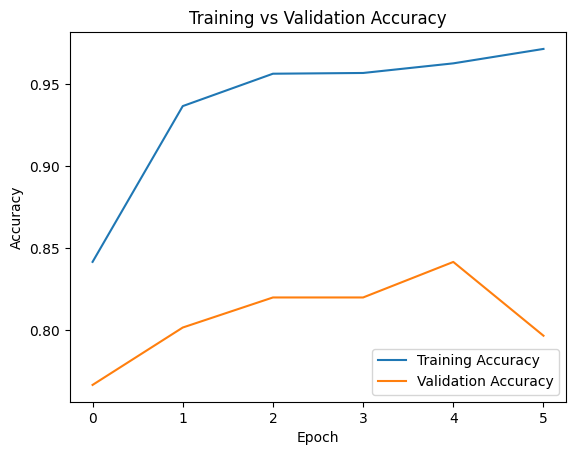

In [ ]:
#Accuracy Graph for Pre-trained model
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

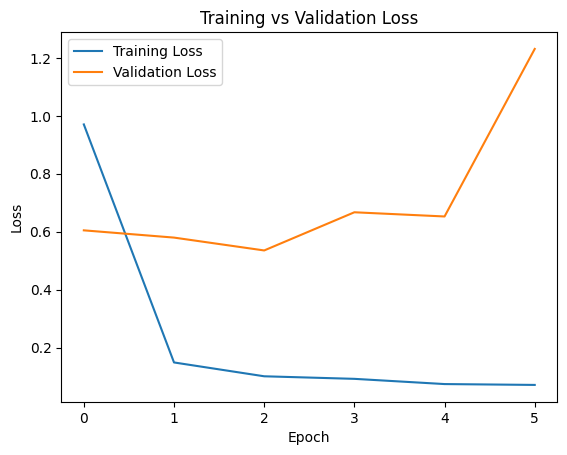

In [ ]:
#Loss Graph for Pre-trained model
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#Classification Report
predictions_mobilenet = model_mobilenet.predict(val_generator_mobilenet)
predicted_classes_mobilenet = (predictions_mobilenet > 0.5).astype(int).flatten()
true_classes_mobilenet = val_generator_mobilenet.classes

print(classification_report(true_classes_mobilenet, predicted_classes_mobilenet))

19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       360
           1       0.82      0.70      0.76       240

    accuracy                           0.82       600
   macro avg       0.82      0.80      0.81       600
weighted avg       0.82      0.82      0.82       600



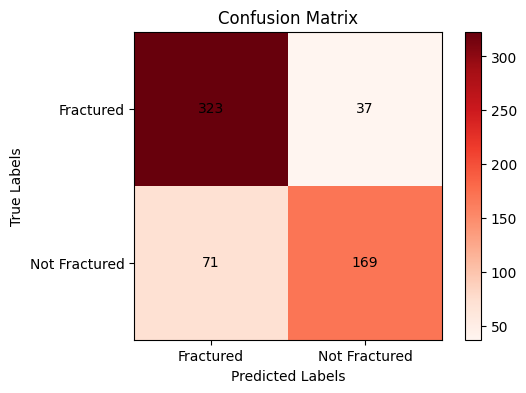

In [ ]:
#Confusion Matrix with Heatmap for Pre-trained model
cm = confusion_matrix(true_classes_mobilenet, predicted_classes_mobilenet)
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Fractured', 'Not Fractured'])
plt.yticks([0, 1], ['Fractured', 'Not Fractured'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

for i in range(2):
  for j in range(2):
    plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.show()